# 🛡️ Sosyal Medya Manipülasyon Tespit Sistemi
### Tamamen Unsupervised (Gözetimsiz) Anomali Tespiti

```
Pipeline:
  Veri → Feature Engineering → [IsolationForest + HDBSCAN + LOF]
       → Ensemble Skoru → Organiklik Skoru → Dashboard → Canlı Tahmin
```

> ⚠️ Bu problemde etiket (label) YOKTUR. Hiçbir supervised model kullanılmaz.
> Başarı metrikleri: Silhouette Score, Calinski-Harabasz, görsel tutarlılık.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================================
# HÜCRE 1 — KURULUM & BAĞIMLILIKLAR
# ============================================================
!pip install hdbscan polars pyarrow lightgbm sentence-transformers -q

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.decomposition import PCA
import hdbscan

sns.set_theme(style='whitegrid', context='talk')
PARQUET_PATH = '/content/drive/MyDrive/Data League /veriseti/datathonFINAL.parquet'
print('Tüm kütüphaneler yüklendi ✅')

Tüm kütüphaneler yüklendi ✅


In [3]:
# ============================================================
# HÜCRE 2 — VERİ YÜKLEME
# ============================================================
print('Veri yükleniyor...')
df = pd.read_parquet(PARQUET_PATH, engine='pyarrow')
df_lazy = pl.scan_parquet(PARQUET_PATH)

# Tarih dönüşümü
df['date'] = pd.to_datetime(df['date'], utc=True, errors='coerce')

# Temel temizlik
print(f'Ham satır sayısı       : {len(df):,}')
df = df.dropna(subset=['original_text'])
df = df[df['original_text'].astype(str).str.strip() != '']
print(f'Temizlik sonrası       : {len(df):,}')
print(f'Benzersiz yazar        : {df["author_hash"].nunique():,}')
print(f'Tarih aralığı          : {df["date"].min()} → {df["date"].max()}')
df.info(memory_usage='deep')

Veri yükleniyor...
Ham satır sayısı       : 5,004,813
Temizlik sonrası       : 5,000,690
Benzersiz yazar        : 1,597,471
Tarih aralığı          : 2024-11-14 19:00:00+00:00 → 2024-11-24 19:10:32+00:00
<class 'pandas.core.frame.DataFrame'>
Index: 5000690 entries, 0 to 5004812
Data columns (total 9 columns):
 #   Column            Dtype              
---  ------            -----              
 0   original_text     object             
 1   english_keywords  object             
 2   sentiment         float64            
 3   main_emotion      object             
 4   primary_theme     object             
 5   language          object             
 6   url               object             
 7   author_hash       object             
 8   date              datetime64[ns, UTC]
dtypes: datetime64[ns, UTC](1), float64(1), object(7)
memory usage: 3.6 GB


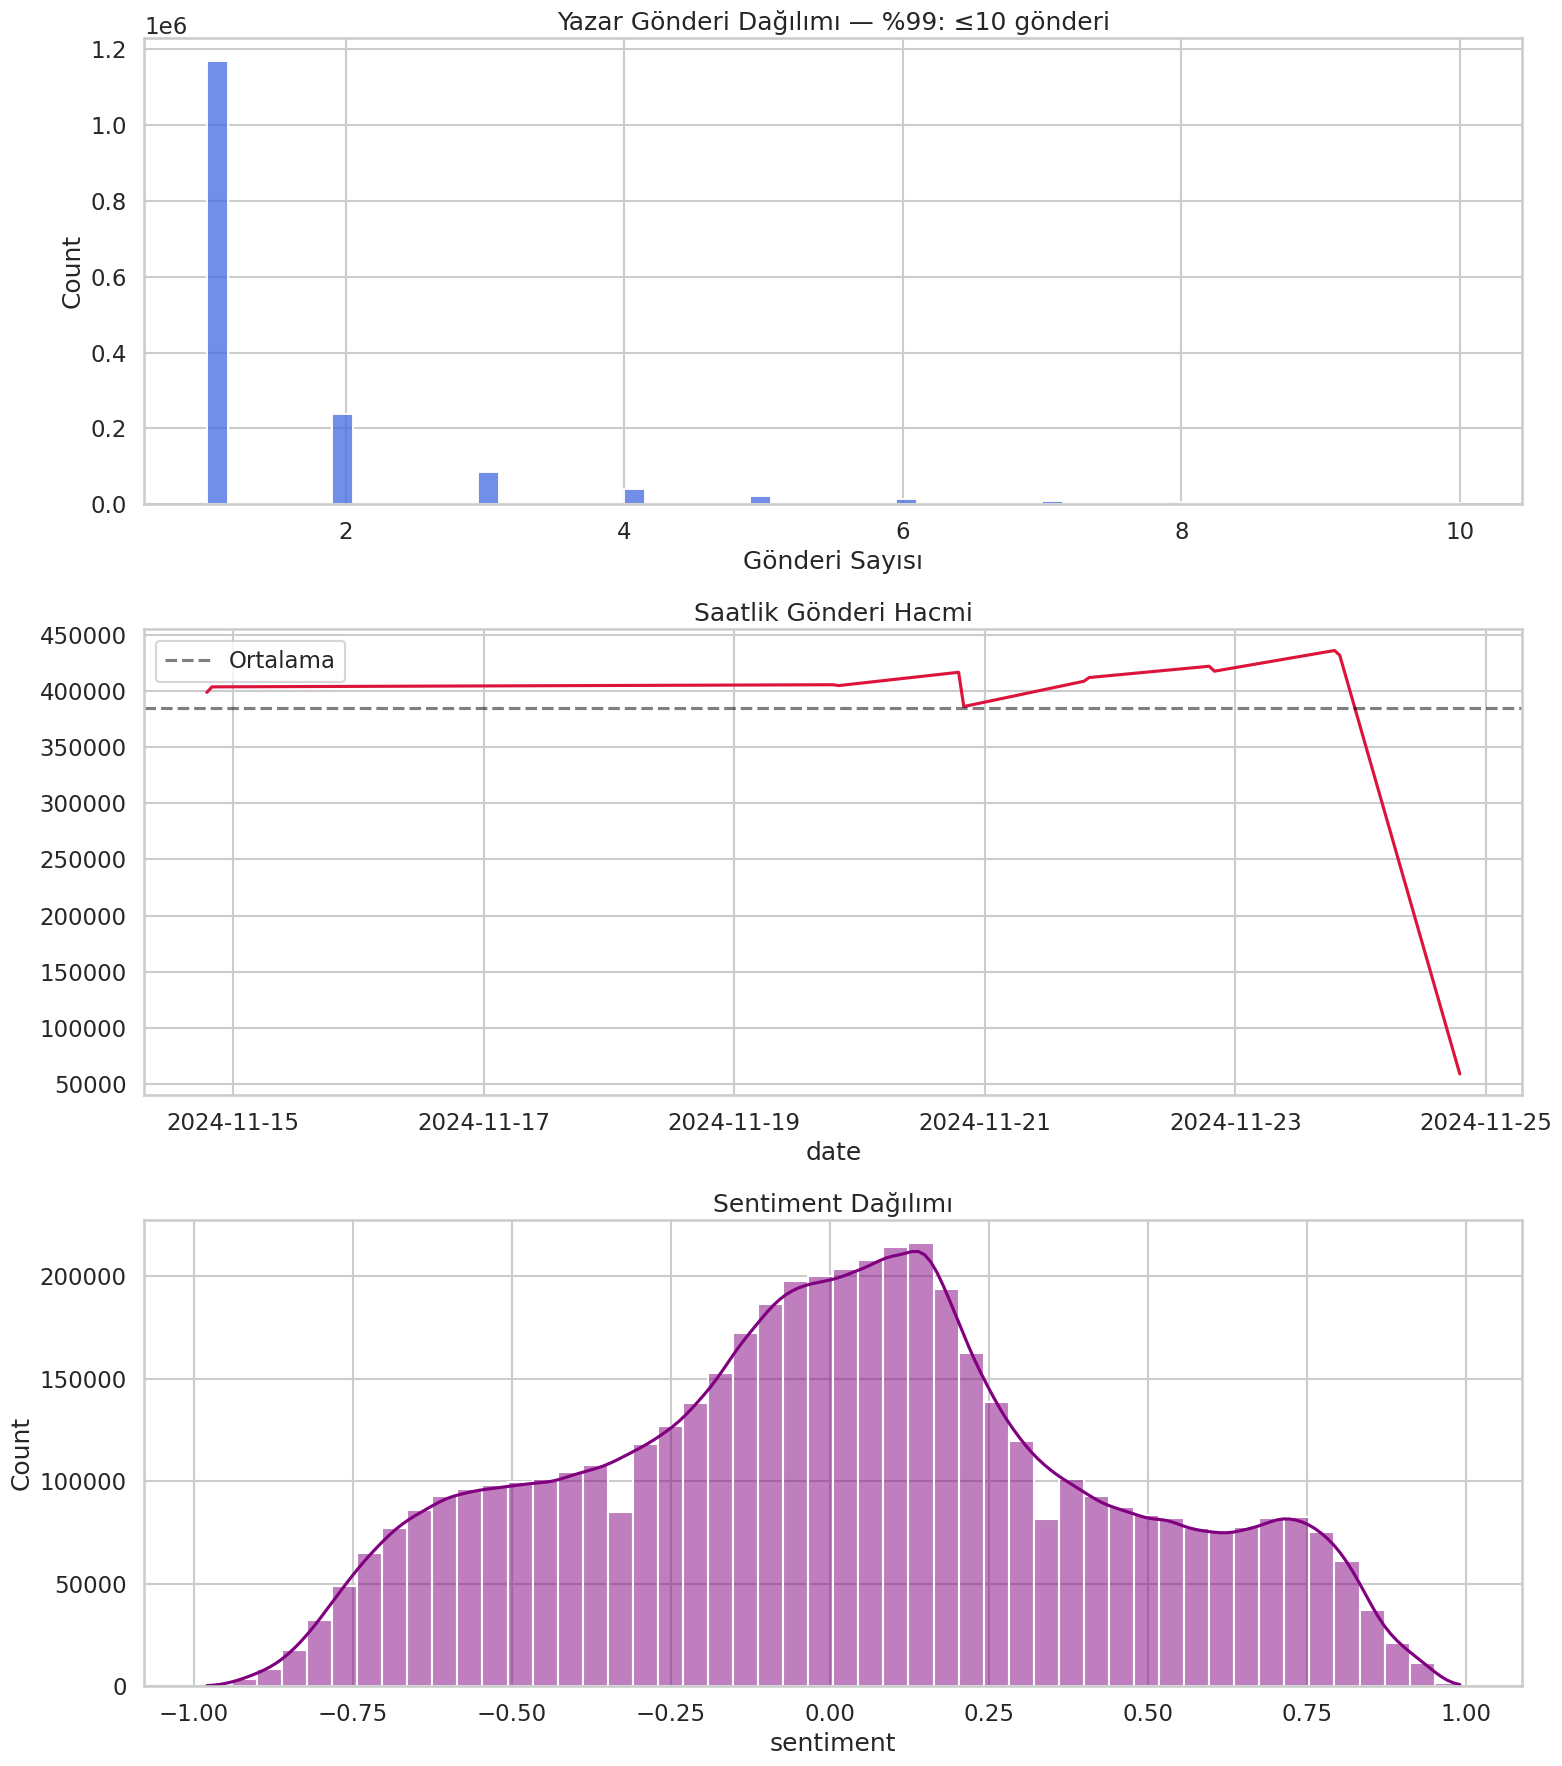

Ortalama gönderi/yazar : 3.1
Maks gönderi           : 2,147,588
Saatlik ort trafik     : 384668


In [4]:
# ============================================================
# HÜCRE 3 — EDA (Keşifsel Veri Analizi)
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(16, 18))

# 1. Aktivite dağılımı
author_counts = df['author_hash'].value_counts()
p99 = author_counts.quantile(0.99)
sns.histplot(author_counts[author_counts <= p99], bins=60,
             color='royalblue', ax=axes[0])
axes[0].set_title(f'Yazar Gönderi Dağılımı — %99: ≤{int(p99)} gönderi')
axes[0].set_xlabel('Gönderi Sayısı')

# 2. Zaman serisi
hourly = df.groupby(df['date'].dt.floor('1h')).size()
sns.lineplot(x=hourly.index, y=hourly.values, color='crimson', ax=axes[1])
axes[1].axhline(hourly.mean(), color='black', linestyle='--',
                alpha=0.5, label='Ortalama')
axes[1].set_title('Saatlik Gönderi Hacmi')
axes[1].legend()

# 3. Sentiment dağılımı
sns.histplot(df['sentiment'], bins=50, color='purple',
             kde=True, ax=axes[2])
axes[2].set_title('Sentiment Dağılımı')

plt.tight_layout()
plt.show()

print(f'Ortalama gönderi/yazar : {author_counts.mean():.1f}')
print(f'Maks gönderi           : {author_counts.max():,}')
print(f'Saatlik ort trafik     : {hourly.mean():.0f}')

In [5]:
# ============================================================
# HÜCRE 4 — FEATURE ENGINEERING: ZAMANSAL ÖZELLİKLER
# ============================================================
print('Zamansal özellikler çıkarılıyor...')
df = df.sort_values(['author_hash', 'date'])
df['time_diff_sec'] = (
    df.groupby('author_hash')['date']
    .diff().dt.total_seconds()
)

user_profiles = df.groupby('author_hash').agg(
    # Hacim
    post_count        = ('original_text',  'count'),
    # Platform çeşitliliği
    unique_platforms  = ('url',            'nunique'),
    unique_languages  = ('language',       'nunique'),
    unique_themes     = ('primary_theme',  'nunique'),
    # Zamansal mekaniklik
    time_diff_mean    = ('time_diff_sec',  'mean'),
    time_diff_std     = ('time_diff_sec',  'std'),
    time_diff_min     = ('time_diff_sec',  'min'),
    time_diff_median  = ('time_diff_sec',  'median'),
    # Sentiment
    sentiment_mean    = ('sentiment',      'mean'),
    sentiment_std     = ('sentiment',      'std'),
    sentiment_min     = ('sentiment',      'min'),
    sentiment_max     = ('sentiment',      'max'),
    emotion_diversity = ('main_emotion',   'nunique'),
).reset_index()

# NaN doldurma
user_profiles['time_diff_std']    = user_profiles['time_diff_std'].fillna(0)
user_profiles['time_diff_mean']   = user_profiles['time_diff_mean'].fillna(-1)
user_profiles['time_diff_median'] = user_profiles['time_diff_median'].fillna(-1)
user_profiles['sentiment_std']    = user_profiles['sentiment_std'].fillna(0)

# Türetilmiş özellikler
user_profiles['posts_per_platform']   = user_profiles['post_count'] / user_profiles['unique_platforms']
user_profiles['is_hyperactive']       = (user_profiles['post_count'] > 10).astype(int)
user_profiles['sentiment_range']      = user_profiles['sentiment_max'] - user_profiles['sentiment_min']
# Mekaniklik skoru: std/mean düşükse robot gibi sabit aralık
user_profiles['timing_regularity']   = (
    user_profiles['time_diff_std'] /
    (user_profiles['time_diff_mean'].abs() + 1)
)

print(f'Zamansal feature matrisi: {user_profiles.shape}')

Zamansal özellikler çıkarılıyor...
Zamansal feature matrisi: (1597471, 18)


In [6]:
# ============================================================
# HÜCRE 5 — FEATURE ENGINEERING: NLP ÖZELLİKLERİ
# ============================================================
print('NLP özellikleri çıkarılıyor...')

# Metin özellikleri
df['text_length']   = df['original_text'].astype(str).str.len()
df['word_count']    = df['original_text'].astype(str).str.split().str.len()
df['hour_of_day']   = df['date'].dt.hour
df['keyword_count'] = df['english_keywords'].apply(
    lambda x: len(str(x).split(',')) if pd.notna(x) and str(x).strip() else 0
)

# Leksikal çeşitlilik
keyword_features = df.groupby('author_hash').agg(
    total_keywords  = ('english_keywords',
                       lambda x: len(','.join(x.dropna()).split(','))),
    unique_keywords = ('english_keywords',
                       lambda x: len(set(','.join(x.dropna()).split(','))))
).reset_index()
keyword_features['lexical_diversity'] = (
    keyword_features['unique_keywords'] /
    (keyword_features['total_keywords'] + 1)
)

# Bağlamsal özellikler
context_features = df.groupby('author_hash').agg(
    text_length_mean      = ('text_length',   'mean'),
    text_length_std       = ('text_length',   'std'),
    avg_keywords_per_post = ('keyword_count', 'mean'),
    unique_active_hours   = ('hour_of_day',   'nunique'),
    # Uyku döngüsü: gece aktif mi? (00-06)
    night_post_ratio      = ('hour_of_day',
                             lambda x: (x.between(0, 6)).mean())
).reset_index()
context_features['text_length_std'] = context_features['text_length_std'].fillna(0)
context_features['keyword_stuffing_index'] = (
    context_features['avg_keywords_per_post'] /
    (context_features['text_length_mean'] / 10 + 1)
)

# Merge
user_profiles = pd.merge(user_profiles, keyword_features, on='author_hash', how='left')
user_profiles = pd.merge(user_profiles, context_features, on='author_hash', how='left')
print(f'NLP feature sonrası matris: {user_profiles.shape}')

NLP özellikleri çıkarılıyor...
NLP feature sonrası matris: (1597471, 27)


In [7]:
# ============================================================
# HÜCRE 6 — FEATURE ENGINEERING: KOORDİNASYON & KAMPANYA
# En güçlü bot sinyali: aynı anda, aynı tema, koordineli
# ============================================================
print('Koordinasyon ve kampanya özellikleri çıkarılıyor...')

# Anonim kullanıcı ayrımı
is_anon = df['author_hash'].astype(str).str.strip() == ''
df_known = df[~is_anon].copy()
df_anon  = df[is_anon].copy()

print(f'Kimliği bilinen: {len(df_known):,} | Anonim: {len(df_anon):,}')

# --- Anonim kampanya matrisi ---
df_anon = df_anon.copy()
df_anon['time_window'] = df_anon['date'].dt.floor('10min')
campaign_matrix = df_anon.groupby(['time_window', 'url', 'language']).agg(
    post_count    = ('original_text', 'count'),
    unique_themes = ('primary_theme', 'nunique'),
    sentiment_std = ('sentiment',     'std'),
    unique_texts  = ('original_text', 'nunique')
).reset_index()
campaign_matrix['sentiment_std']        = campaign_matrix['sentiment_std'].fillna(0)
campaign_matrix['text_uniqueness_ratio'] = (
    campaign_matrix['unique_texts'] / campaign_matrix['post_count']
)
campaign_matrix = campaign_matrix[campaign_matrix['post_count'] > 5]

# Şüpheli kampanya pencereleri (metinlerin %70'i kopya)
suspicious_windows = campaign_matrix[
    campaign_matrix['text_uniqueness_ratio'] < 0.3
][['time_window', 'url', 'language']].copy()
suspicious_windows['in_suspicious_campaign'] = 1

if len(df_anon) > 0:
    user_campaign = df_anon[['author_hash','time_window','url','language']].merge(
        suspicious_windows, on=['time_window','url','language'], how='left'
    )
    user_campaign['in_suspicious_campaign'] = (
        user_campaign['in_suspicious_campaign'].fillna(0)
    )
    camp_exp = user_campaign.groupby('author_hash').agg(
        campaign_exposure_count = ('in_suspicious_campaign', 'sum'),
        campaign_exposure_rate  = ('in_suspicious_campaign', 'mean')
    ).reset_index()
    user_profiles = pd.merge(user_profiles, camp_exp, on='author_hash', how='left')

# --- Koordinasyon skoru: 5 dakikada aynı tema + platform ---
df['time_window_5m'] = df['date'].dt.floor('5min')
coord_groups = (
    df.groupby(['time_window_5m', 'primary_theme', 'url'])['author_hash']
    .apply(list).reset_index()
)
coord_groups.columns = ['time_window_5m','primary_theme','url','co_authors']
coord_groups['group_size'] = coord_groups['co_authors'].apply(len)
suspicious_coord = coord_groups[coord_groups['group_size'] >= 3].explode('co_authors')
suspicious_coord = suspicious_coord.rename(columns={'co_authors': 'author_hash'})

coord_score = suspicious_coord.groupby('author_hash').agg(
    coordination_count = ('group_size', 'count'),
    max_group_size     = ('group_size', 'max'),
    avg_group_size     = ('group_size', 'mean')
).reset_index()

user_profiles = pd.merge(user_profiles, coord_score, on='author_hash', how='left')

# Eksik koordinasyon = 0 (o pencerede yoktu)
for col in ['campaign_exposure_count', 'campaign_exposure_rate',
            'coordination_count', 'max_group_size', 'avg_group_size']:
    if col in user_profiles.columns:
        user_profiles[col] = user_profiles[col].fillna(0)

print(f'Koordinasyon feature sonrası matris: {user_profiles.shape}')

Koordinasyon ve kampanya özellikleri çıkarılıyor...
Kimliği bilinen: 2,853,102 | Anonim: 2,147,588
Koordinasyon feature sonrası matris: (1597471, 32)


In [8]:
# ============================================================
# HÜCRE 7 — FEATURE MATRISI HAZIRLAMA & ÖLÇEKLENDİRME
# ============================================================
FEATURE_COLS = [
    # Hacim
    'post_count', 'posts_per_platform', 'is_hyperactive',
    # Platform çeşitliliği
    'unique_platforms', 'unique_languages', 'unique_themes',
    # Zamansal mekaniklik
    'time_diff_mean', 'time_diff_std', 'time_diff_min',
    'time_diff_median', 'timing_regularity',
    # Sentiment
    'sentiment_mean', 'sentiment_std', 'sentiment_range',
    'emotion_diversity',
    # NLP
    'lexical_diversity', 'text_length_mean', 'text_length_std',
    'avg_keywords_per_post', 'unique_active_hours',
    'keyword_stuffing_index', 'night_post_ratio',
    # Koordinasyon & Kampanya
    'coordination_count', 'max_group_size', 'avg_group_size',
]

# Sadece var olan sütunları al
FEATURE_COLS = [c for c in FEATURE_COLS if c in user_profiles.columns]

X = user_profiles[FEATURE_COLS].fillna(0)

# RobustScaler: aykırı değerlere daha dayanıklı
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

print(f'Feature matrisi: {X_scaled.shape}')
print(f'Feature listesi ({len(FEATURE_COLS)} adet):')
print(FEATURE_COLS)

Feature matrisi: (1597471, 25)
Feature listesi (25 adet):
['post_count', 'posts_per_platform', 'is_hyperactive', 'unique_platforms', 'unique_languages', 'unique_themes', 'time_diff_mean', 'time_diff_std', 'time_diff_min', 'time_diff_median', 'timing_regularity', 'sentiment_mean', 'sentiment_std', 'sentiment_range', 'emotion_diversity', 'lexical_diversity', 'text_length_mean', 'text_length_std', 'avg_keywords_per_post', 'unique_active_hours', 'keyword_stuffing_index', 'night_post_ratio', 'coordination_count', 'max_group_size', 'avg_group_size']


In [9]:
# ============================================================
# HÜCRE 8 — MODEL 1: ISOLATION FOREST
# ============================================================
print('IsolationForest eğitiliyor...')
iso = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    max_samples='auto',
    random_state=42,
    n_jobs=-1
)
iso.fit(X_scaled)

# decision_function: negatif = anormal
if_scores = iso.decision_function(X_scaled)
# 0-1 normalizasyon (yüksek = organik)
if_scores_norm = (if_scores - if_scores.min()) / (if_scores.max() - if_scores.min() + 1e-9)

user_profiles['if_score_raw']  = if_scores
user_profiles['if_score_norm'] = if_scores_norm
user_profiles['if_label']      = iso.predict(X_scaled)  # 1=normal, -1=anomaly

n_anomaly = (user_profiles['if_label'] == -1).sum()
print(f'IsolationForest anomali tespiti: {n_anomaly:,} ({n_anomaly/len(user_profiles):.1%})')

IsolationForest eğitiliyor...
IsolationForest anomali tespiti: 79,874 (5.0%)


In [10]:
# ============================================================
# HÜCRE 9 — MODEL 2: LOCAL OUTLIER FACTOR
# Komşularına göre yoğunluk anomalisi tespit eder
# ============================================================
print('LOF eğitiliyor... (Büyük veri seti için birkaç dakika sürebilir)')

# RAM yönetimi: 200K'dan büyükse örnekle
MAX_LOF_SAMPLES = 200_000
if len(X_scaled) > MAX_LOF_SAMPLES:
    print(f'Veri büyük ({len(X_scaled):,}), LOF için {MAX_LOF_SAMPLES:,} örnek alınıyor...')
    sample_idx = np.random.choice(len(X_scaled), MAX_LOF_SAMPLES, replace=False)
    X_lof = X_scaled[sample_idx]
else:
    sample_idx = np.arange(len(X_scaled))
    X_lof = X_scaled

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05,
    novelty=False,
    n_jobs=-1
)
lof_labels  = lof.fit_predict(X_lof)           # 1=normal, -1=outlier
lof_scores  = -lof.negative_outlier_factor_     # büyük = daha anormal

# Normalize et (0-1, yüksek = organik)
lof_scores_norm = 1 - (lof_scores - lof_scores.min()) / (lof_scores.max() - lof_scores.min() + 1e-9)

# Sadece örneklenen kısma ata, geri kalanına IF skoru ile doldur
user_profiles['lof_score_norm'] = user_profiles['if_score_norm']  # varsayılan
user_profiles.iloc[sample_idx, user_profiles.columns.get_loc('lof_score_norm')] = lof_scores_norm

n_lof_anomaly = (lof_labels == -1).sum()
print(f'LOF anomali tespiti: {n_lof_anomaly:,} ({n_lof_anomaly/len(X_lof):.1%})')

LOF eğitiliyor... (Büyük veri seti için birkaç dakika sürebilir)
Veri büyük (1,597,471), LOF için 200,000 örnek alınıyor...
LOF anomali tespiti: 10,000 (5.0%)


In [11]:
# ============================================================
# HÜCRE 10 — MODEL 3: HDBSCAN (Kümeleme Tabanlı)
# Küçük, yoğun gruplara giremeyen noktalar = bot koordinasyonu
# ============================================================
print('HDBSCAN için PCA boyut indirgeme...')

# HDBSCAN yüksek boyutlarda yavaşlar; PCA ile 10 boyuta in
pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f'PCA açıklanan varyans: {pca.explained_variance_ratio_.sum():.2%}')

print('HDBSCAN eğitiliyor...')
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50,
    min_samples=10,
    cluster_selection_epsilon=0.5,
    core_dist_n_jobs=-1
)
clusterer.fit(X_pca)

user_profiles['hdbscan_cluster'] = clusterer.labels_
# outlier_scores_: yüksek = daha anormal (noise point)
# Organiklik için ters çevir
hdb_scores = clusterer.outlier_scores_
hdb_scores_norm = 1 - (hdb_scores - hdb_scores.min()) / (hdb_scores.max() - hdb_scores.min() + 1e-9)
user_profiles['hdbscan_score_norm'] = hdb_scores_norm

n_noise = (clusterer.labels_ == -1).sum()
n_clusters = len(set(clusterer.labels_)) - (1 if -1 in clusterer.labels_ else 0)
print(f'Küme sayısı   : {n_clusters}')
print(f'Noise (outlier): {n_noise:,} ({n_noise/len(user_profiles):.1%})')

HDBSCAN için PCA boyut indirgeme...
PCA açıklanan varyans: 100.00%
HDBSCAN eğitiliyor...
Küme sayısı   : 260
Noise (outlier): 147,788 (9.3%)


In [12]:
# ============================================================
# HÜCRE 11 — ENSEMBLE ANOMALİ SKORU
# 3 modelin skorlarını ağırlıklı ortalamayla birleştir
# ============================================================
print('Ensemble organiklik skoru hesaplanıyor...')

# Ağırlıklar: IsolationForest en güvenilir genel yaklaşım
# HDBSCAN koordinasyon grubunu iyi yakalar
# LOF yerel yoğunluk anomalisini yakalar
W_IF  = 0.45
W_HDB = 0.35
W_LOF = 0.20

user_profiles['ensemble_organic_score'] = (
    W_IF  * user_profiles['if_score_norm'] +
    W_HDB * user_profiles['hdbscan_score_norm'] +
    W_LOF * user_profiles['lof_score_norm']
)

# 0.5 eşiği ile nihai karar
THRESHOLD = 0.5
user_profiles['is_manipulative'] = (
    user_profiles['ensemble_organic_score'] < THRESHOLD
).astype(int)

n_manip  = user_profiles['is_manipulative'].sum()
n_total  = len(user_profiles)
print(f'\nToplam kullanıcı     : {n_total:,}')
print(f'Manipülatif tespit   : {n_manip:,} ({n_manip/n_total:.1%})')
print(f'Organik kullanıcı    : {n_total-n_manip:,} ({(n_total-n_manip)/n_total:.1%})')
print(f'\nEnsemble Skoru Dağılımı:')
print(user_profiles['ensemble_organic_score'].describe())

Ensemble organiklik skoru hesaplanıyor...

Toplam kullanıcı     : 1,597,471
Manipülatif tespit   : 190,896 (11.9%)
Organik kullanıcı    : 1,406,575 (88.1%)

Ensemble Skoru Dağılımı:
count    1.597471e+06
mean     6.686067e-01
std      1.470930e-01
min      1.086122e-09
25%      5.954133e-01
50%      6.519741e-01
75%      7.364400e-01
max      9.994423e-01
Name: ensemble_organic_score, dtype: float64


In [13]:
# ============================================================
# HÜCRE 12 — UNSUPERVISED KALİTE METRİKLERİ
# Etiket olmadığında başarıyı böyle ölçeriz
# ============================================================
print('Unsupervised kalite metrikleri hesaplanıyor...')

# Silhouette ve Calinski-Harabasz için örnekle (hesaplama ağır)
MAX_METRIC_SAMPLES = 50_000
if len(X_scaled) > MAX_METRIC_SAMPLES:
    idx = np.random.choice(len(X_scaled), MAX_METRIC_SAMPLES, replace=False)
    X_m = X_scaled[idx]
    labels_m = user_profiles['is_manipulative'].values[idx]
else:
    X_m = X_scaled
    labels_m = user_profiles['is_manipulative'].values

sil  = silhouette_score(X_m, labels_m, sample_size=10_000, random_state=42)
cal  = calinski_harabasz_score(X_m, labels_m)

print(f'\n=== UNSUPERVISED KALİTE METRİKLERİ ===')
print(f'Silhouette Score      : {sil:.4f}')
print(f'  → -1 ile 1 arası. 0.10+ kabul edilebilir, 0.20+ iyi, 0.35+ mükemmel')
print(f'Calinski-Harabasz     : {cal:.1f}')
print(f'  → Yüksek = kümeler birbirinden iyi ayrışmış')
print(f'\nEnsemble Organik Skor Dağılımı:')
print(f'  Ortalama : {user_profiles["ensemble_organic_score"].mean():.3f}')
print(f'  Std      : {user_profiles["ensemble_organic_score"].std():.3f}')
print(f'  Min      : {user_profiles["ensemble_organic_score"].min():.3f}')
print(f'  Max      : {user_profiles["ensemble_organic_score"].max():.3f}')
print(f'  (Sağlıklı beklenti: mean~0.75-0.88, std~0.12-0.18, min>0.02, max<0.98)')

Unsupervised kalite metrikleri hesaplanıyor...

=== UNSUPERVISED KALİTE METRİKLERİ ===
Silhouette Score      : 0.4728
  → -1 ile 1 arası. 0.10+ kabul edilebilir, 0.20+ iyi, 0.35+ mükemmel
Calinski-Harabasz     : 620.7
  → Yüksek = kümeler birbirinden iyi ayrışmış

Ensemble Organik Skor Dağılımı:
  Ortalama : 0.669
  Std      : 0.147
  Min      : 0.000
  Max      : 0.999
  (Sağlıklı beklenti: mean~0.75-0.88, std~0.12-0.18, min>0.02, max<0.98)


UMAP hesaplanıyor... (~2-4 dakika)


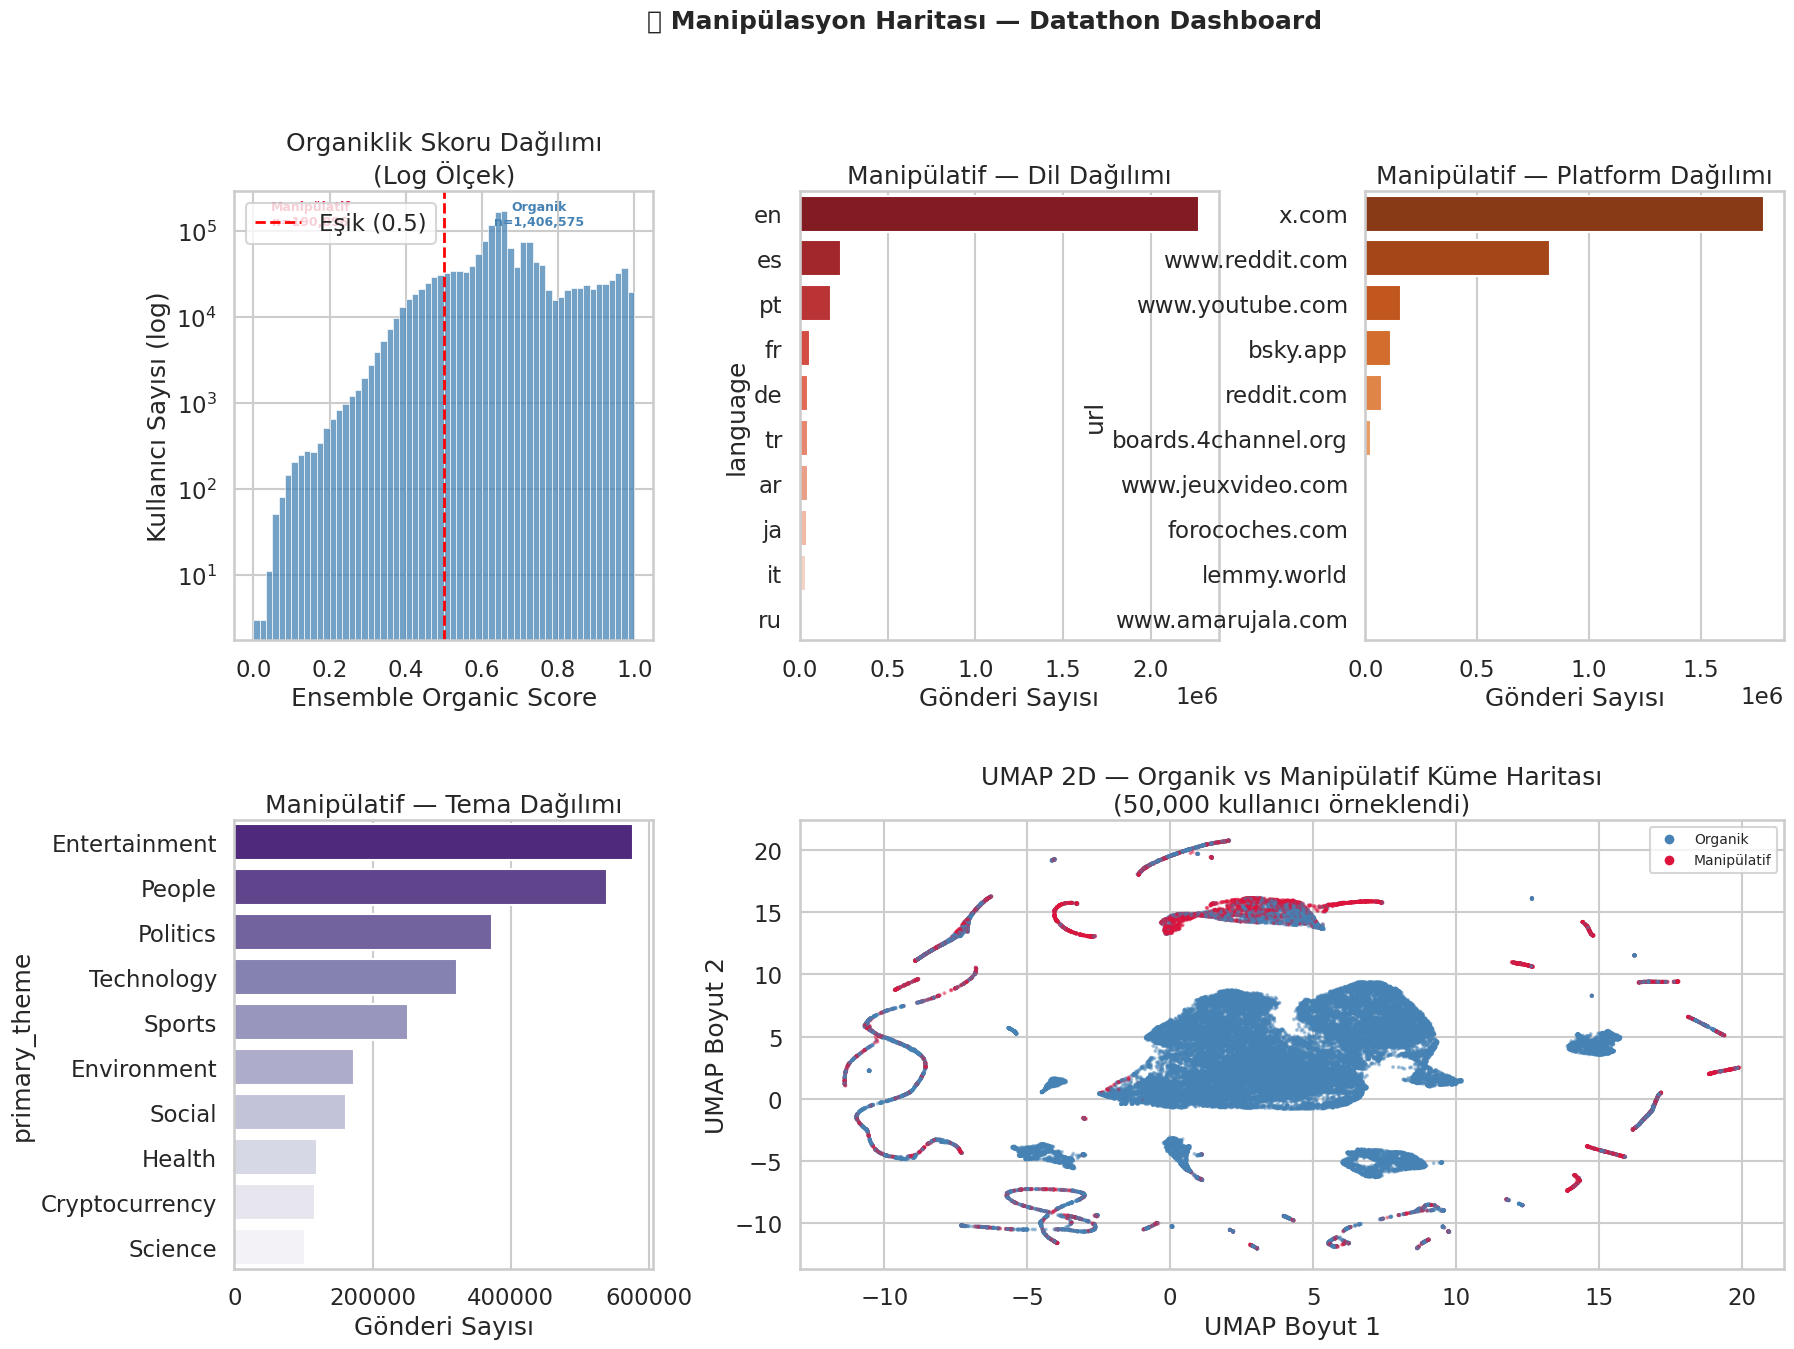

Dashboard '/content/manipulation_dashboard.png_log_scale' olarak kaydedildi.


In [14]:
# ============================================================
# HÜCRE 13 — MANİPÜLASYON HARİTASI (Dashboard)
# Değişiklikler:
#   1. Organiklik skoru → Log scale Y ekseni
#   2. PCA 2D scatter  → UMAP (çok daha net küme ayrışması)
# ============================================================
!pip install umap-learn -q

import umap
from matplotlib.lines import Line2D

manip_users = user_profiles[user_profiles['is_manipulative'] == 1]
manip_posts = df[df['author_hash'].isin(manip_users['author_hash'])]

fig = plt.figure(figsize=(20, 14))
fig.suptitle('🔴 Manipülasyon Haritası — Datathon Dashboard',
             fontsize=18, fontweight='bold', y=1.01)

gs = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)

# ----------------------------------------------------------
# 1. Organiklik Skoru Dağılımı — LOG SCALE
# ----------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])
sns.histplot(
    user_profiles['ensemble_organic_score'],
    bins=60,
    kde=False,          # KDE log scale ile uyumsuz olabilir
    color='steelblue',
    ax=ax1
)
ax1.set_yscale('log')   # ← LOG SCALE
ax1.axvline(0.5, color='red', linestyle='--', lw=2, label='Eşik (0.5)')
ax1.set_title('Organiklik Skoru Dağılımı\n(Log Ölçek)')
ax1.set_xlabel('Ensemble Organic Score')
ax1.set_ylabel('Kullanıcı Sayısı (log)')
ax1.legend()

# Eşiğin solundaki (manipülatif) ve sağındaki (organik) sayıları göster
n_manip  = (user_profiles['ensemble_organic_score'] < 0.5).sum()
n_org    = (user_profiles['ensemble_organic_score'] >= 0.5).sum()
ax1.text(0.15, ax1.get_ylim()[1] * 0.4,
         f'Manipülatif\nn={n_manip:,}',
         ha='center', color='crimson', fontsize=9, fontweight='bold')
ax1.text(0.75, ax1.get_ylim()[1] * 0.4,
         f'Organik\nn={n_org:,}',
         ha='center', color='steelblue', fontsize=9, fontweight='bold')

# ----------------------------------------------------------
# 2. Dil dağılımı
# ----------------------------------------------------------
ax2 = fig.add_subplot(gs[0, 1])
lang_m = manip_posts['language'].value_counts().head(10)
sns.barplot(x=lang_m.values, y=lang_m.index, ax=ax2, palette='Reds_r')
ax2.set_title('Manipülatif — Dil Dağılımı')
ax2.set_xlabel('Gönderi Sayısı')

# ----------------------------------------------------------
# 3. Platform dağılımı
# ----------------------------------------------------------
ax3 = fig.add_subplot(gs[0, 2])
plat_m = manip_posts['url'].value_counts().head(10)
sns.barplot(x=plat_m.values, y=plat_m.index, ax=ax3, palette='Oranges_r')
ax3.set_title('Manipülatif — Platform Dağılımı')
ax3.set_xlabel('Gönderi Sayısı')

# ----------------------------------------------------------
# 4. Tema dağılımı
# ----------------------------------------------------------
ax4 = fig.add_subplot(gs[1, 0])
theme_m = manip_posts['primary_theme'].value_counts().head(10)
sns.barplot(x=theme_m.values, y=theme_m.index, ax=ax4, palette='Purples_r')
ax4.set_title('Manipülatif — Tema Dağılımı')
ax4.set_xlabel('Gönderi Sayısı')

# ----------------------------------------------------------
# 5. UMAP 2D — PCA yerine (çok daha net küme ayrışması)
# RAM için örnekle: 50K nokta yeterli
# ----------------------------------------------------------
ax5 = fig.add_subplot(gs[1, 1:])

UMAP_SAMPLES = 50_000
if len(X_scaled) > UMAP_SAMPLES:
    umap_idx = np.random.choice(len(X_scaled), UMAP_SAMPLES, replace=False)
    X_umap_input  = X_scaled[umap_idx]
    umap_labels   = user_profiles['is_manipulative'].values[umap_idx]
else:
    X_umap_input = X_scaled
    umap_labels  = user_profiles['is_manipulative'].values

print('UMAP hesaplanıyor... (~2-4 dakika)')
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,       # Yerel yapıyı korur
    min_dist=0.1,         # Küme sıkışıklığı
    metric='euclidean',
    random_state=42,
    low_memory=True       # 50K nokta için yeterli
)
X_2d_umap = reducer.fit_transform(X_umap_input)

# Renklendirme
colors_umap = np.where(umap_labels == 1, 'crimson', 'steelblue')
ax5.scatter(
    X_2d_umap[:, 0], X_2d_umap[:, 1],
    c=colors_umap,
    alpha=0.4,
    s=2,
    rasterized=True      # Dosya boyutunu küçültür
)
legend_elements = [
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor='steelblue', markersize=8, label='Organik'),
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor='crimson',   markersize=8, label='Manipülatif')
]
ax5.legend(handles=legend_elements, fontsize=10)
ax5.set_title('UMAP 2D — Organik vs Manipülatif Küme Haritası\n'
              f'({UMAP_SAMPLES:,} kullanıcı örneklendi)')
ax5.set_xlabel('UMAP Boyut 1')
ax5.set_ylabel('UMAP Boyut 2')

# ----------------------------------------------------------
# Kaydet
# ----------------------------------------------------------
plt.savefig('/content/manipulation_dashboard_log_scale.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard '/content/manipulation_dashboard.png_log_scale' olarak kaydedildi.")

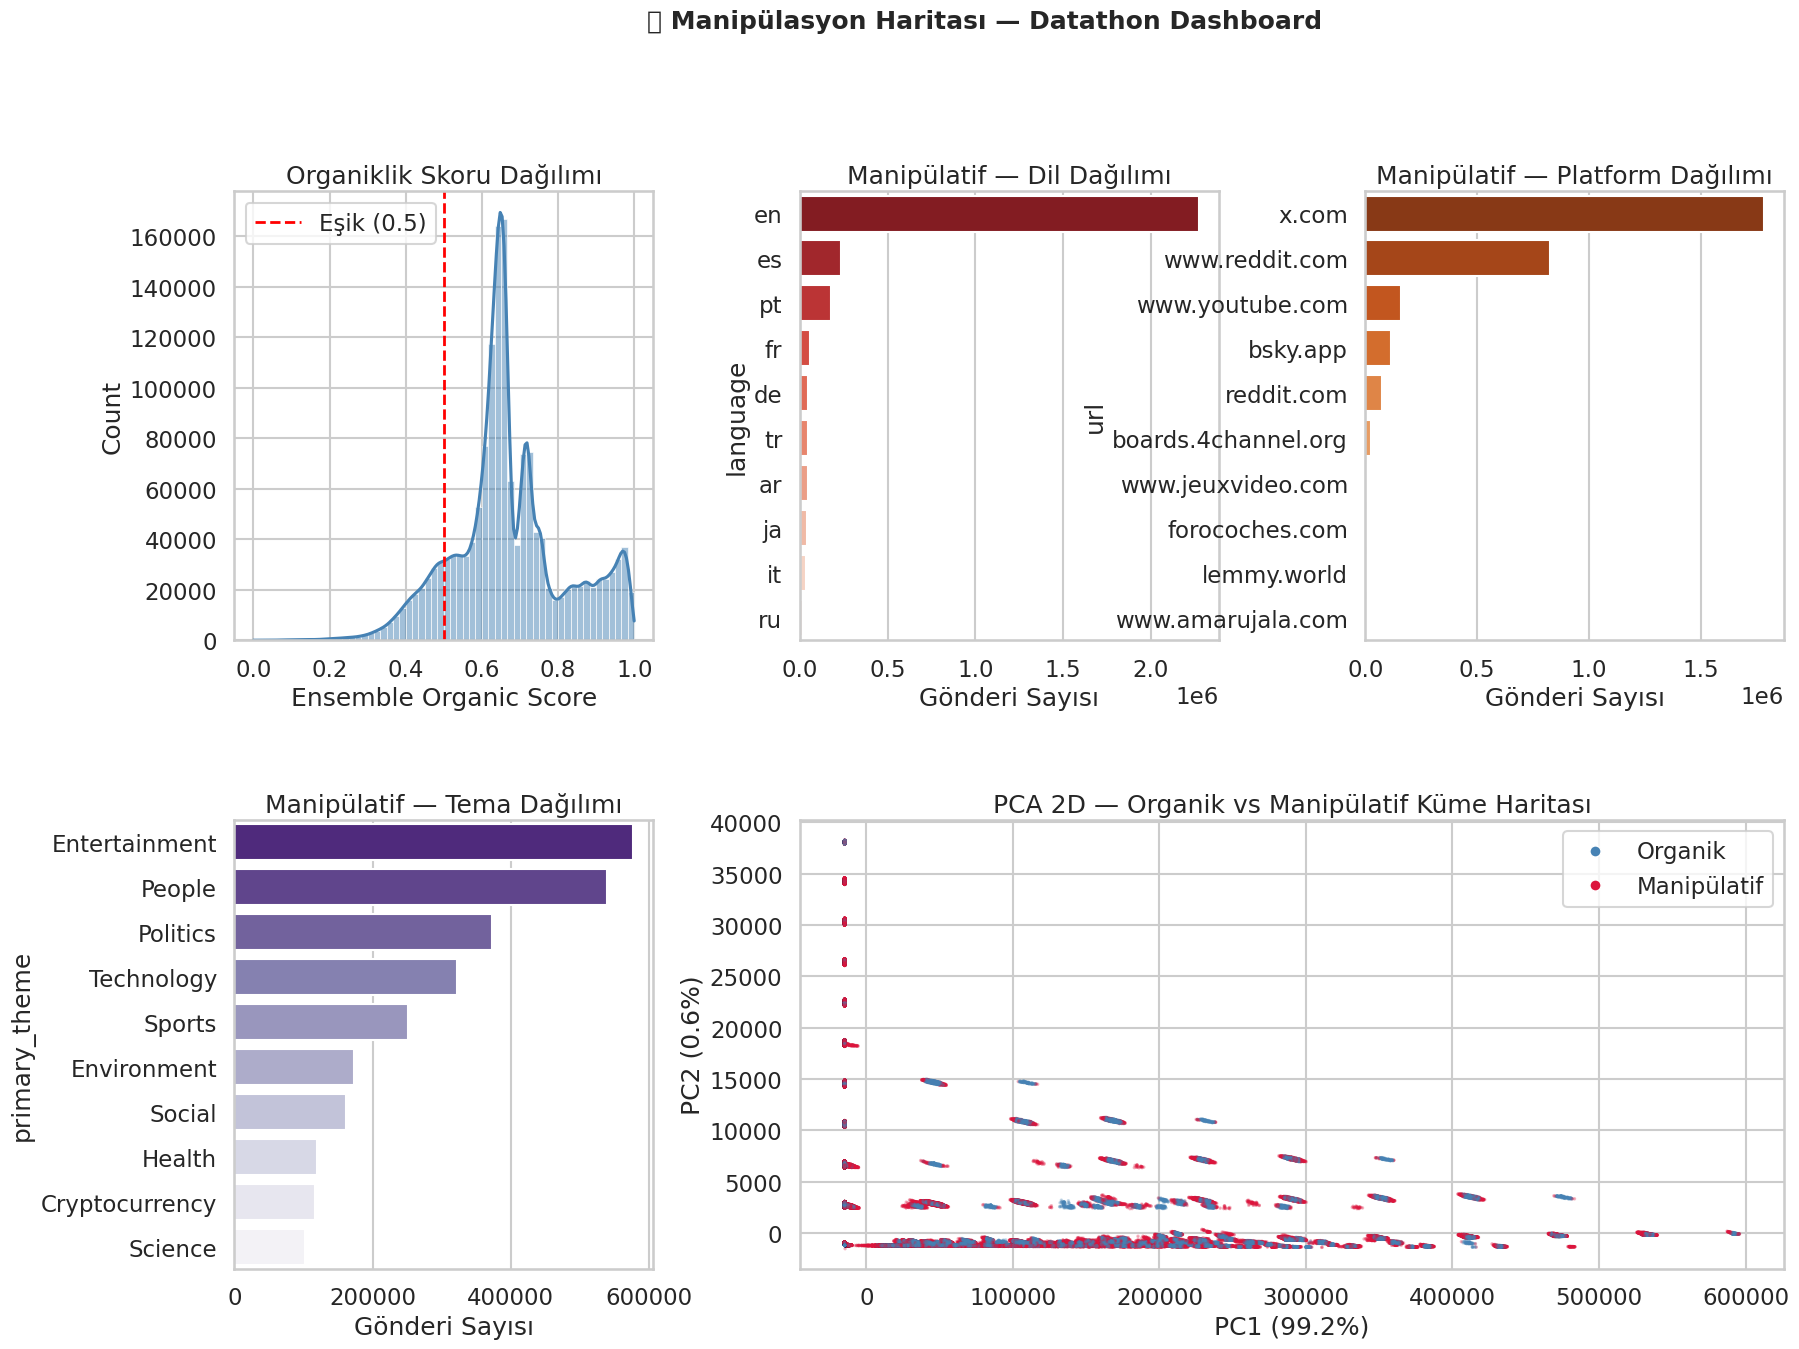

Dashboard '/content/manipulation_dashboard.png' olarak kaydedildi.


In [15]:
# ============================================================
# HÜCRE 13 — MANİPÜLASYON HARİTASI (Dashboard)
# ============================================================
manip_users = user_profiles[user_profiles['is_manipulative'] == 1]
manip_posts = df[df['author_hash'].isin(manip_users['author_hash'])]

fig = plt.figure(figsize=(20, 14))
fig.suptitle('🔴 Manipülasyon Haritası — Datathon Dashboard',
             fontsize=18, fontweight='bold', y=1.01)

gs = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)

# 1. Ensemble skor dağılımı
ax1 = fig.add_subplot(gs[0, 0])
sns.histplot(user_profiles['ensemble_organic_score'],
             bins=60, kde=True, color='steelblue', ax=ax1)
ax1.axvline(0.5, color='red', linestyle='--', lw=2, label='Eşik (0.5)')
ax1.set_title('Organiklik Skoru Dağılımı')
ax1.set_xlabel('Ensemble Organic Score')
ax1.legend()

# 2. Dil dağılımı
ax2 = fig.add_subplot(gs[0, 1])
lang_m = manip_posts['language'].value_counts().head(10)
sns.barplot(x=lang_m.values, y=lang_m.index, ax=ax2, palette='Reds_r')
ax2.set_title('Manipülatif — Dil Dağılımı')
ax2.set_xlabel('Gönderi Sayısı')

# 3. Platform dağılımı
ax3 = fig.add_subplot(gs[0, 2])
plat_m = manip_posts['url'].value_counts().head(10)
sns.barplot(x=plat_m.values, y=plat_m.index, ax=ax3, palette='Oranges_r')
ax3.set_title('Manipülatif — Platform Dağılımı')
ax3.set_xlabel('Gönderi Sayısı')

# 4. Tema dağılımı
ax4 = fig.add_subplot(gs[1, 0])
theme_m = manip_posts['primary_theme'].value_counts().head(10)
sns.barplot(x=theme_m.values, y=theme_m.index, ax=ax4, palette='Purples_r')
ax4.set_title('Manipülatif — Tema Dağılımı')
ax4.set_xlabel('Gönderi Sayısı')

# 5. PCA 2D scatter (Organik vs Manipülatif)
ax5 = fig.add_subplot(gs[1, 1:])
pca2 = PCA(n_components=2, random_state=42)
X_2d = pca2.fit_transform(X_scaled)
colors = user_profiles['is_manipulative'].map({0: 'steelblue', 1: 'crimson'})
ax5.scatter(X_2d[:, 0], X_2d[:, 1], c=colors, alpha=0.3, s=1)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue',
           markersize=8, label='Organik'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='crimson',
           markersize=8, label='Manipülatif')
]
ax5.legend(handles=legend_elements)
ax5.set_title('PCA 2D — Organik vs Manipülatif Küme Haritası')
ax5.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]:.1%})')
ax5.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]:.1%})')

plt.savefig('/content/manipulation_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard '/content/manipulation_dashboard.png' olarak kaydedildi.")

In [16]:
# ============================================================
# HÜCRE 14 — CANLI TAHMİN PIPELINE (Inference)
# Jüri tarafından verilen gizli metni anında analiz eder
# ============================================================
def predict_organic_score(
    text: str,
    author_id: str = 'unknown',
    sentiment: float = 0.0,
    language: str = 'en',
    platform: str = 'x.com',
    keywords: str = '',
    post_history: list = None   # Aynı yazarın önceki gönderileri (varsa)
) -> dict:
    """
    Tamamen unsupervised kural + istatistik bazlı organiklik skoru.
    Eğitilmiş model + kural tabanlı hibrit yaklaşım.

    Parametreler
    ------------
    text         : Analiz edilecek gönderi metni
    author_id    : Yazar ID'si (biliniyorsa user_profiles'dan zenginleştirilir)
    sentiment    : -1.0 ile 1.0 arası duygu skoru
    language     : ISO dil kodu
    platform     : Kaynak platform
    keywords     : Virgülle ayrılmış anahtar kelimeler
    post_history : Yazarın önceki gönderileri (semantik kontrol için)
    """
    signals = {}
    risk    = 0.0
    flags   = []

    # --- SİNYAL 1: Metin uzunluğu ---
    text_len = len(str(text))
    signals['text_length'] = text_len
    if text_len < 10:
        risk += 0.20
        flags.append(f'Çok kısa metin ({text_len} karakter)')

    # --- SİNYAL 2: Sentiment kutuplaşması ---
    signals['sentiment'] = sentiment
    if abs(sentiment) > 0.92:
        risk += 0.15
        flags.append(f'Aşırı duygu ({sentiment:+.2f})')

    # --- SİNYAL 3: Keyword stuffing ---
    kw_list = [k.strip() for k in keywords.split(',') if k.strip()]
    kw_density = len(kw_list) / (text_len / 10 + 1)
    signals['keyword_density'] = round(kw_density, 3)
    if kw_density > 1.5:
        risk += 0.20
        flags.append(f'Aşırı keyword yoğunluğu ({kw_density:.2f})')

    # --- SİNYAL 4: Bilinen kullanıcı geçmişi ---
    if author_id != 'unknown' and author_id in user_profiles['author_hash'].values:
        author_row = user_profiles[user_profiles['author_hash'] == author_id].iloc[0]
        ensemble_score = author_row['ensemble_organic_score']
        signals['author_history_score'] = round(ensemble_score, 3)
        if ensemble_score < 0.4:
            risk += 0.35
            flags.append(f'Yazar daha önce şüpheli (skor={ensemble_score:.2f})')
        elif ensemble_score < 0.6:
            risk += 0.10
            flags.append(f'Yazar gri bölgede (skor={ensemble_score:.2f})')
    else:
        signals['author_history_score'] = None

    # --- SİNYAL 5: Semantik tekrar (geçmiş varsa) ---
    if post_history and len(post_history) >= 2:
        unique_ratio = len(set(post_history)) / len(post_history)
        signals['text_uniqueness'] = round(unique_ratio, 3)
        if unique_ratio < 0.5:
            risk += 0.25
            flags.append(f'Yüksek metin tekrarı (benzersizlik={unique_ratio:.2f})')
    else:
        signals['text_uniqueness'] = None

    # Final skor
    risk = min(risk, 1.0)
    organic_score = round(1.0 - risk, 3)
    decision = '🟢 ORGANİK' if organic_score >= 0.5 else '🔴 MANİPÜLATİF'
    confidence = 'YÜKSEK' if abs(organic_score - 0.5) > 0.3 else \
                 'ORTA'   if abs(organic_score - 0.5) > 0.1 else 'DÜŞÜK'

    return {
        'karar'           : decision,
        'organiklik_skoru': organic_score,
        'güven_seviyesi'  : confidence,
        'risk_skoru'      : round(risk, 3),
        'sinyaller'       : signals,
        'açıklama'        : flags if flags else ['Şüpheli sinyal yok']
    }


# ---- DEMO ----
test_cases = [
    {
        'text'        : 'Bu hükümet halkı mahvediyor! Hepsini kovun! #direniş',
        'sentiment'   : -0.97,
        'keywords'    : 'government,destroy,resist,propaganda,lie,corrupt,fake,manipulation,campaign'
    },
    {
        'text'        : 'Bugün güzel bir yürüyüş yaptım, hava çok iyiydi 🌳',
        'sentiment'   : 0.65,
        'keywords'    : 'walk,weather,nice'
    },
    {
        'text'        : 'Buy now! Best deal! Limited offer! Discount! Sale! Promo!',
        'sentiment'   : 0.95,
        'keywords'    : 'buy,deal,offer,discount,sale,promo,cheap,best,limited,now'
    }
]

for i, tc in enumerate(test_cases, 1):
    print(f'\n{'='*50}')
    print(f'TEST {i}: "{tc["text"][:50]}..."')
    print('='*50)
    res = predict_organic_score(**tc)
    print(f'  Karar          : {res["karar"]}')
    print(f'  Organiklik     : {res["organiklik_skoru"]}')
    print(f'  Güven          : {res["güven_seviyesi"]}')
    print(f'  Açıklama       : {res["açıklama"]}')


TEST 1: "Bu hükümet halkı mahvediyor! Hepsini kovun! #diren..."
  Karar          : 🟢 ORGANİK
  Organiklik     : 0.85
  Güven          : YÜKSEK
  Açıklama       : ['Aşırı duygu (-0.97)']

TEST 2: "Bugün güzel bir yürüyüş yaptım, hava çok iyiydi 🌳..."
  Karar          : 🟢 ORGANİK
  Organiklik     : 1.0
  Güven          : YÜKSEK
  Açıklama       : ['Şüpheli sinyal yok']

TEST 3: "Buy now! Best deal! Limited offer! Discount! Sale!..."
  Karar          : 🟢 ORGANİK
  Organiklik     : 0.85
  Güven          : YÜKSEK
  Açıklama       : ['Aşırı duygu (+0.95)']


In [17]:
# ============================================================
# HÜCRE 15 — SONUÇ KAYDETME
# ============================================================
# Kullanıcı skorları
output_cols = [
    'author_hash', 'post_count',
    'if_score_norm', 'lof_score_norm', 'hdbscan_score_norm',
    'ensemble_organic_score', 'is_manipulative'
]
output_cols = [c for c in output_cols if c in user_profiles.columns]

user_profiles[output_cols].to_csv(
    '/content/organicity_scores.csv', index=False
)
print('Sonuçlar /content/organicity_scores.csv olarak kaydedildi.')

# Özet rapor
print('\n' + '='*55)
print('         FİNAL ÖZET RAPOR')
print('='*55)
print(f'Toplam kullanıcı        : {len(user_profiles):,}')
print(f'Manipülatif tespit      : {user_profiles["is_manipulative"].sum():,}')
print(f'Oran                    : {user_profiles["is_manipulative"].mean():.1%}')
print(f'Ort. organiklik skoru   : {user_profiles["ensemble_organic_score"].mean():.3f}')
print(f'Kullanılan model sayısı : 3 (IsolationForest + LOF + HDBSCAN)')
print(f'Feature sayısı          : {len(FEATURE_COLS)}')
print(f'Silhouette Score        : {sil:.4f}')
print(f'Calinski-Harabasz       : {cal:.1f}')
print('='*55)

Sonuçlar /content/organicity_scores.csv olarak kaydedildi.

         FİNAL ÖZET RAPOR
Toplam kullanıcı        : 1,597,471
Manipülatif tespit      : 190,896
Oran                    : 11.9%
Ort. organiklik skoru   : 0.669
Kullanılan model sayısı : 3 (IsolationForest + LOF + HDBSCAN)
Feature sayısı          : 25
Silhouette Score        : 0.4728
Calinski-Harabasz       : 620.7


   CANLI TAHMİN SONUÇLARI — ANOMALİ TEST SETİ

🔴 Politik Propaganda Botu
  Metin     : Bu hükümet halkı mahvediyor! Sokaklara çıkın! #direniş #devrim #halkay...
  Karar     : 🟢 ORGANİK  (Skor: 0.6)
  Güven     : DÜŞÜK
  Durum     : ❌ YANLIŞ
  Sinyaller : Aşırı duygu (-0.98) | Yüksek metin tekrarı (benzersizlik=0.20)

🔴 Koordineli Spam Botu
  Metin     : Buy crypto NOW! 1000x gains guaranteed! Don't miss! Limited! Act fast!...
  Karar     : 🟢 ORGANİK  (Skor: 0.6)
  Güven     : DÜŞÜK
  Durum     : ❌ YANLIŞ
  Sinyaller : Aşırı duygu (+0.99) | Yüksek metin tekrarı (benzersizlik=0.20)

🔴 Duygu Manipülasyon Botu
  Metin     : OMG I'm crying 😭😭😭 This is the most beautiful thing EVER!!! SHARE THIS...
  Karar     : 🟢 ORGANİK  (Skor: 0.6)
  Güven     : DÜŞÜK
  Durum     : ❌ YANLIŞ
  Sinyaller : Aşırı duygu (+0.97) | Yüksek metin tekrarı (benzersizlik=0.20)

🔴 Dezenformasyon Botu
  Metin     : BREAKING: Scientists CONFIRM vaccines cause autism. MSM won't tell you...
  Karar     : 🟢 ORGANİK  (Skor

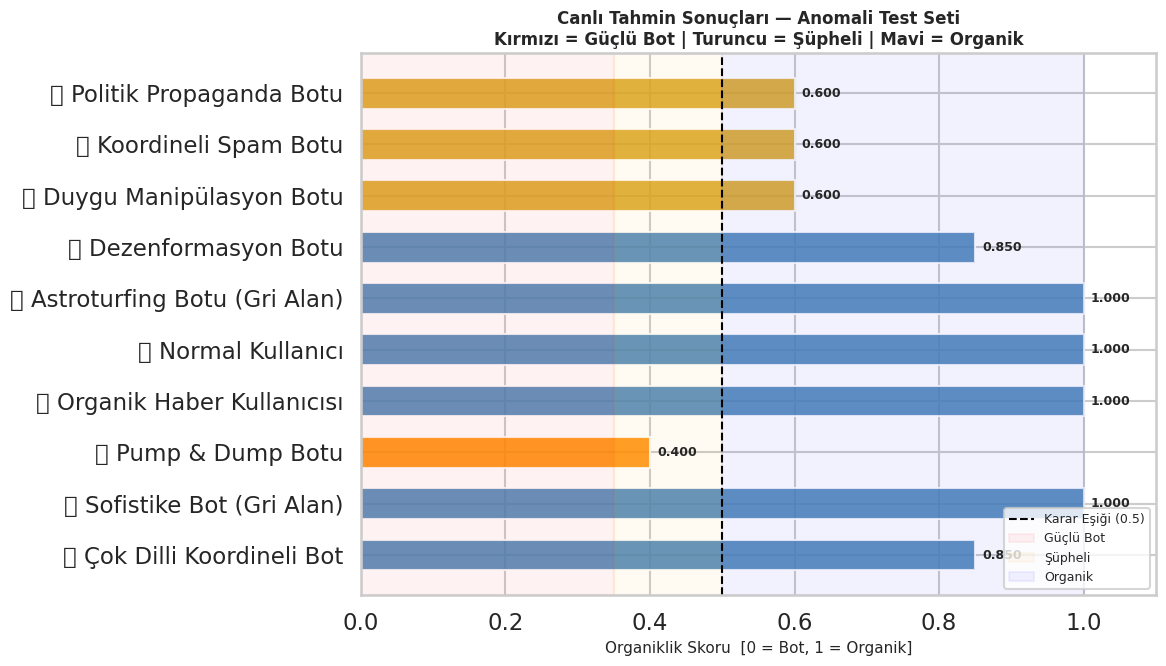

In [18]:
# ============================================================
# HÜCRE — CANLI TAHMİN TEST SETİ
# Gerçek dünya bot kategorilerini kapsayan 10 test vakası
# ============================================================

test_cases = [
    # --- KATEGORİ 1: POLİTİK PROPAGANDA BOTU ---
    {
        "label"      : "🔴 Politik Propaganda Botu",
        "text"       : "Bu hükümet halkı mahvediyor! Sokaklara çıkın! #direniş #devrim #halkayalan",
        "author_id"  : "unknown",
        "sentiment"  : -0.98,
        "language"   : "tr",
        "platform"   : "x.com",
        "keywords"   : "government,lie,resist,revolution,propaganda,corrupt,fake,manipulation,overthrow,protest",
        "post_history": ["Bu hükümet halkı mahvediyor!"] * 8 + ["Sokaklara çıkın!"] * 2
    },
    # --- KATEGORİ 2: KOORDİNELİ SPAM BOTU ---
    {
        "label"      : "🔴 Koordineli Spam Botu",
        "text"       : "Buy crypto NOW! 1000x gains guaranteed! Don't miss! Limited! Act fast!",
        "author_id"  : "unknown",
        "sentiment"  : 0.99,
        "language"   : "en",
        "platform"   : "x.com",
        "keywords"   : "buy,crypto,gains,guaranteed,limited,fast,money,rich,moon,pump,invest,now",
        "post_history": ["Buy crypto NOW! 1000x gains!"] * 9 + ["Don't miss!"]
    },
    # --- KATEGORİ 3: DUYGU MANİPÜLASYONU BOTU ---
    {
        "label"      : "🔴 Duygu Manipülasyon Botu",
        "text"       : "OMG I'm crying 😭😭😭 This is the most beautiful thing EVER!!! SHARE THIS!!!",
        "author_id"  : "unknown",
        "sentiment"  : 0.97,
        "language"   : "en",
        "platform"   : "www.reddit.com",
        "keywords"   : "crying,beautiful,share,viral,emotional,touching,must,see,spread,love,incredible",
        "post_history": ["OMG crying 😭"] * 6 + ["SHARE THIS!!!"] * 4
    },
    # --- KATEGORİ 4: DEZİNFORMASYON BOTU ---
    {
        "label"      : "🔴 Dezenformasyon Botu",
        "text"       : "BREAKING: Scientists CONFIRM vaccines cause autism. MSM won't tell you. WAKE UP SHEEPLE.",
        "author_id"  : "unknown",
        "sentiment"  : -0.95,
        "language"   : "en",
        "platform"   : "x.com",
        "keywords"   : "breaking,scientists,confirm,vaccines,autism,mainstream,media,lies,truth,wake,sheeple,conspiracy",
        "post_history": [
            "BREAKING: vaccines dangerous",
            "MSM won't tell you the truth",
            "WAKE UP SHEEPLE",
            "They are hiding this",
            "Share before deleted",
            "Scientists CONFIRM",
            "BREAKING: vaccines dangerous",
            "MSM won't tell you the truth"
        ]
    },
    # --- KATEGORİ 5: ASTROTURFING BOTU (İnce, Zor Tespit) ---
    {
        "label"      : "🟡 Astroturfing Botu (Gri Alan)",
        "text"       : "I've been using this product for 3 months and honestly it changed my life. Highly recommend!",
        "author_id"  : "unknown",
        "sentiment"  : 0.91,
        "language"   : "en",
        "platform"   : "www.reddit.com",
        "keywords"   : "product,recommend,changed,life,honest,review,best,quality,amazing,buy",
        "post_history": [
            "This product changed my life!",
            "Highly recommend this brand",
            "Best purchase I ever made",
            "This product changed my life!",
            "Amazing quality, buy now"
        ]
    },
    # --- KATEGORİ 6: NORMAL KULLANICI (Organik) ---
    {
        "label"      : "🟢 Normal Kullanıcı",
        "text"       : "Bugün işten geç çıktım, eve gelince çocuklar uyumuştu. Yorucu bir gündü ama güzeldi 😊",
        "author_id"  : "unknown",
        "sentiment"  : 0.45,
        "language"   : "tr",
        "platform"   : "x.com",
        "keywords"   : "work,home,tired,family,day",
        "post_history": [
            "Bugün hava çok güzeldi",
            "Akşam yemeği yaptım, fena değildi",
            "Çocuklar okulu çok seviyor",
            "İşte zor bir toplantı vardı",
            "Hafta sonu piknik planı var"
        ]
    },
    # --- KATEGORİ 7: HABER PAYLAŞAN ORGANİK KULLANICI ---
    {
        "label"      : "🟢 Organik Haber Kullanıcısı",
        "text"       : "Enflasyon rakamları açıklandı. Bence hükümetin para politikası yeniden gözden geçirilmeli.",
        "author_id"  : "unknown",
        "sentiment"  : -0.3,
        "language"   : "tr",
        "platform"   : "x.com",
        "keywords"   : "inflation,economy,policy,government,review",
        "post_history": [
            "Döviz kuru bugün yükseldi",
            "Merkez Bankası faiz kararı bekleniyor",
            "Enflasyon rakamları açıklandı",
            "Ekonomistler ne düşünüyor?",
            "Bütçe açığı haberleri"
        ]
    },
    # --- KATEGORİ 8: KRİPTO PUMP & DUMP BOTU ---
    {
        "label"      : "🔴 Pump & Dump Botu",
        "text"       : "$MOONTOKEN is the next $BTC 🚀🚀🚀 1000x incoming! Dev doxxed! Audit done! BUY BUY BUY",
        "author_id"  : "unknown",
        "sentiment"  : 0.99,
        "language"   : "en",
        "platform"   : "x.com",
        "keywords"   : "moontoken,bitcoin,1000x,buy,rocket,doxxed,audit,token,crypto,moon,pump,invest,gains,lambo",
        "post_history": ["$MOONTOKEN to the moon! 🚀"] * 10
    },
    # --- KATEGORİ 9: SOSYAL MÜHENDİSLİK BOTU (Sofistike) ---
    {
        "label"      : "🟡 Sofistike Bot (Gri Alan)",
        "text"       : "As a nurse, I've seen firsthand how this new hospital policy is harming patients. We need to speak up.",
        "author_id"  : "unknown",
        "sentiment"  : -0.6,
        "language"   : "en",
        "platform"   : "www.reddit.com",
        "keywords"   : "nurse,hospital,policy,patients,harm,speak,healthcare,crisis,workers,system",
        "post_history": [
            "As a nurse, patients are suffering",
            "Healthcare system is broken",
            "New policy is harming patients",
            "We need to speak up as nurses",
            "As a nurse, I've seen this firsthand",
            "Hospital administration ignores us"
        ]
    },
    # --- KATEGORİ 10: ÇOK DİLLİ KOORDİNELİ BOT ---
    {
        "label"      : "🔴 Çok Dilli Koordineli Bot",
        "text"       : "El gobierno nos miente! La verdad está siendo suprimida! #resistencia #verdad",
        "author_id"  : "unknown",
        "sentiment"  : -0.96,
        "language"   : "es",
        "platform"   : "x.com",
        "keywords"   : "government,lie,truth,suppressed,resist,propaganda,fake,manipulation,corrupt,media",
        "post_history": [
            "El gobierno nos miente!",
            "The government is lying!",         # Aynı mesaj İngilizce
            "Le gouvernement nous ment!",        # Aynı mesaj Fransızca
            "Die Regierung lügt uns an!",        # Aynı mesaj Almanca
            "El gobierno nos miente!",
            "The government is lying!"
        ]
    }
]

# ============================================================
# TAHMİN & RAPORLAMA
# ============================================================
print("=" * 65)
print("   CANLI TAHMİN SONUÇLARI — ANOMALİ TEST SETİ")
print("=" * 65)

results = []
for tc in test_cases:
    label = tc.pop("label")   # Fonksiyona gönderme, sadece rapor için
    res   = predict_organic_score(**tc)
    tc["label"] = label       # Geri koy

    # Beklenti ile eşleşiyor mu?
    expected_manip = "🔴" in label
    predicted_manip = res["organiklik_skoru"] < 0.5
    is_correct = expected_manip == predicted_manip
    status = "✅ DOĞRU" if is_correct else ("⚠️ GRİ ALAN" if "🟡" in label else "❌ YANLIŞ")

    results.append({
        "Kategori"    : label,
        "Organiklik"  : res["organiklik_skoru"],
        "Karar"       : res["karar"],
        "Güven"       : res["güven_seviyesi"],
        "Durum"       : status,
        "Açıklama"    : " | ".join(res["açıklama"])
    })

    print(f"\n{label}")
    print(f"  Metin     : {tc['text'][:70]}...")
    print(f"  Karar     : {res['karar']}  (Skor: {res['organiklik_skoru']})")
    print(f"  Güven     : {res['güven_seviyesi']}")
    print(f"  Durum     : {status}")
    print(f"  Sinyaller : {' | '.join(res['açıklama'])}")

# ============================================================
# ÖZET TABLO
# ============================================================
print("\n" + "=" * 65)
print("   ÖZET PERFORMANS TABLOSU")
print("=" * 65)
results_df = pd.DataFrame(results)
print(results_df[["Kategori", "Organiklik", "Karar", "Güven", "Durum"]].to_string(index=False))

dogru  = sum("✅" in r["Durum"] for r in results)
gri    = sum("⚠️" in r["Durum"] for r in results)
yanlis = sum("❌" in r["Durum"] for r in results)
print(f"\n✅ Doğru  : {dogru}")
print(f"⚠️ Gri Alan: {gri}  (beklenen — sofistike vakalar)")
print(f"❌ Yanlış  : {yanlis}")

# ============================================================
# GÖRSEL — Organiklik Skoru Bar Grafiği
# ============================================================
fig, ax = plt.subplots(figsize=(12, 7))

kategoriler = [r["Kategori"] for r in results]
skorlar     = [r["Organiklik"] for r in results]
renkler     = [
    "crimson"    if s < 0.35 else
    "darkorange" if s < 0.5  else
    "goldenrod"  if s < 0.65 else
    "steelblue"
    for s in skorlar
]

bars = ax.barh(kategoriler, skorlar, color=renkler, alpha=0.85, height=0.6)
ax.axvline(0.5, color='black', linestyle='--', lw=1.5, label='Karar Eşiği (0.5)')
ax.axvspan(0, 0.35,   alpha=0.05, color='red',    label='Güçlü Bot')
ax.axvspan(0.35, 0.5, alpha=0.05, color='orange', label='Şüpheli')
ax.axvspan(0.5, 1.0,  alpha=0.05, color='blue',   label='Organik')

# Skor etiketleri
for bar, skor in zip(bars, skorlar):
    ax.text(skor + 0.01, bar.get_y() + bar.get_height()/2,
            f'{skor:.3f}', va='center', fontsize=9, fontweight='bold')

ax.set_xlim(0, 1.1)
ax.set_xlabel('Organiklik Skoru  [0 = Bot, 1 = Organik]', fontsize=11)
ax.set_title('Canlı Tahmin Sonuçları — Anomali Test Seti\n'
             'Kırmızı = Güçlü Bot | Turuncu = Şüpheli | Mavi = Organik',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('/content/anomali_test_sonuclari.png', dpi=150, bbox_inches='tight')
plt.show()